# 14. Pixel Sorting: The Aesthetics of the Glitch

Chapter 13 taught the image to degrade politely, in the service of reproduction. Today we let it fail on purpose: one call to a sorting function, aimed at a painting, melts it into cascades of falling color. The trick is deciding where to aim.

## Today's destination

Seurat's *Grande Jatte*, interval-sorted. Inside a chosen brightness band, every column of pixels has been reordered from dark to light, so the painting streams downward like wet paint; outside the band, nothing was touched, so the Sunday strollers survive as ghosts inside the cascade. No pixel was invented or destroyed: every dot of color in this image is one of Seurat's own, in a new place. By the end of today you can aim this failure precisely.

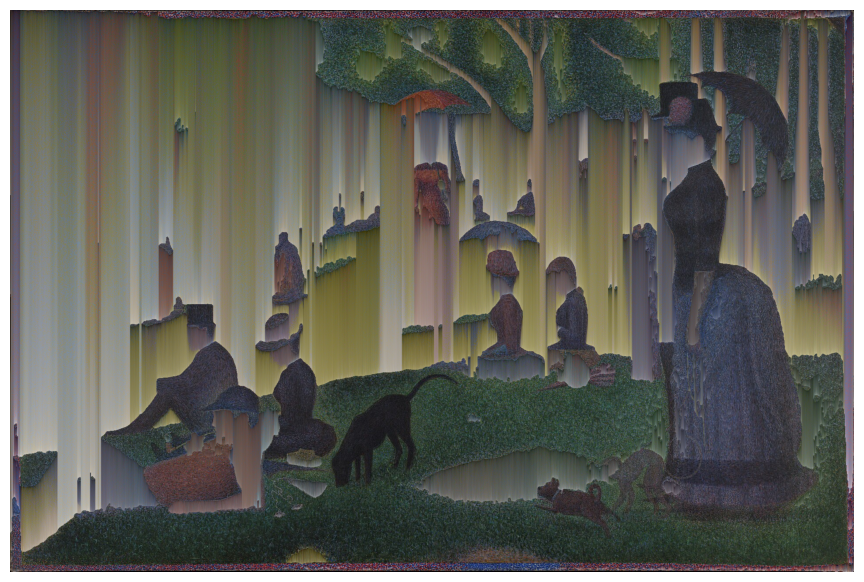

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch14_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(11, 7.3))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: when the medium shows itself

In 1965 **Nam June Paik** set an industrial magnet on top of a seventeen-inch black-and-white television. *Magnet TV* (Whitney Museum of American Art) turns the broadcast image into a writhing abstract bloom: the magnet bends the electron beam, and the set, built to be a transparent window onto elsewhere, suddenly shows you its own insides. Paik, widely regarded as the founder of video art, had already shown "prepared" televisions with deliberately manipulated circuitry at his first solo exhibition (*Exposition of Music – Electronic Television*, Galerie Parnass, Wuppertal, 1963). The lesson, two decades before the personal computer: distorting the electronic image need not be vandalism of art; it can be the art.

The theory arrived with **Rosa Menkman**, whom you brushed past at the end of chapter 13. She calls a glitch a "break from an expected flow": the moment a medium fails is the moment it stops being invisible and shows itself (*Glitch Studies Manifesto*, 2009/2010; *The Glitch Moment(um)*, 2011). Glitch artists cultivate such moments deliberately. **Databending**, for instance, opens an image file in a text or audio editor, edits it as if it were prose or sound, and saves the beautiful wreckage; JPEG files, whose compression packs meaning densely, corrupt the most dramatically.

Our technique for today is younger and gentler: it breaks nothing, it only pretends to. Around 2010 the German artist **Kim Asendorf** wrote a short Processing script that sorted stretches of pixels within an image by brightness, and ran ten mountain photographs found online through it (*Mountain Tour*, 2010). When he open-sourced the code, called ASDFPixelSort, in 2012, the look spread through net culture within months: **pixel sorting** became one of the most recognizable aesthetics of the glitch wave, precisely because it is not a malfunction at all. It is a *simulated* one: deliberate, repeatable, tunable. In other words, exactly this book's kind of object, an algorithm with dials.

Note the reversal from last chapter. Dithering was *controlled* degradation in the service of reproduction: the error was managed, hidden, made humble so that the image would survive a crude printer. The glitch *celebrates* the error and promotes it to subject. Both are children of the same insight, that every image is carried by a fallible process, and the wider mood has a name: the post-digital, a term the composer Kim Cascone borrowed from Nicholas Negroponte and pushed into currency with his essay "The Aesthetics of Failure" (2000), which argued that a medium's character lives in its failures.

## Sorting as an aesthetic operation

Sorting is the least mysterious algorithm in this book: put things in order. What makes it an *artistic* instrument is the question it forces you to answer first: in order *of what*? A pixel is three numbers, and it has no single natural size. You must choose a **key** (Sortierschlüssel), a single number computed per pixel that decides who goes before whom, and every choice is a different artwork:

- **luminance**, the perceived brightness (chapter 13 used PIL's weighted grayscale conversion for exactly this),
- **hue**, the angle around chapter 5's color wheel,
- **saturation**, the distance from gray,
- or any single channel: just the red, just the green.

Watch the operation itself on something small enough to see whole: sixteen grays in arrival order, then the same sixteen grays sorted. Same pixels, different picture.

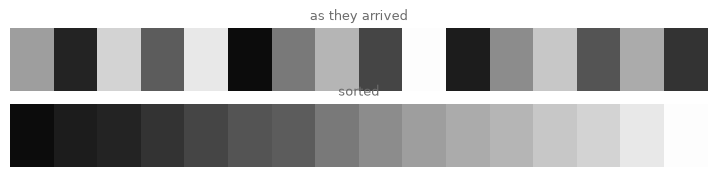

In [2]:
# sorting reorders, it never invents: the same 16 values before and after
import numpy as np

arrival_values = np.array([0.62, 0.14, 0.83, 0.36, 0.91, 0.05, 0.48, 0.71,
                           0.27, 0.99, 0.11, 0.55, 0.78, 0.33, 0.67, 0.20])
# np.sort returns the values in ascending order; the originals are untouched
in_order = np.sort(arrival_values)

fig, axes = plt.subplots(2, 1, figsize=(9, 1.8))
axes[0].imshow(arrival_values[None, :], cmap="gray", vmin=0, vmax=1, aspect="auto")
axes[0].set_title("as they arrived", fontsize=9, color="#6B6B6B")
axes[1].imshow(in_order[None, :], cmap="gray", vmin=0, vmax=1, aspect="auto")
axes[1].set_title("sorted", fontsize=9, color="#6B6B6B")
for ax in axes:
    ax.axis("off")
plt.show()

The top strip is noise; the bottom strip is a gradient. That is the whole phenomenon: **sorting turns texture into gradient**. Every pixel-sorted image you have ever seen is this two-strip figure, scaled up and aimed.

One more tool and we can aim it. A color pixel is a *row* of three numbers, so we cannot sort the pixels directly; we sort the *key* and ask numpy where each value came from. `np.argsort` returns not the sorted values but the **positions that would sort them**, and chapter 12's paired index arrays then let us drag the full RGB rows into that order. This key-versus-payload split is precisely how a spreadsheet sorts whole rows by one column.

In [3]:
# argsort gives the order; fancy indexing drags the RGB payload along
demo_key = np.array([0.62, 0.14, 0.83, 0.36])
order = np.argsort(demo_key)          # positions that would sort the key
print("key:      ", demo_key)
print("order:    ", order, " (read: smallest sits at position 1)")
print("key[order]:", demo_key[order])

key:       [0.62 0.14 0.83 0.36]
order:     [1 3 0 2]  (read: smallest sits at position 1)
key[order]: [0.14 0.36 0.62 0.83]


## The victim

The painting we sort deserves a moment's thought. We use the *Grande Jatte* (chapter 12 stippled it into dots; Seurat had already done so, beginning in 1884). A pointillist surface is the perfect victim for this chapter, because pixel sorting literally re-orders the painter's dots: divisionism promised that color mixes in the eye, and sorting takes the promise apart dot by dot, reassembling the mixture into its spectrum.

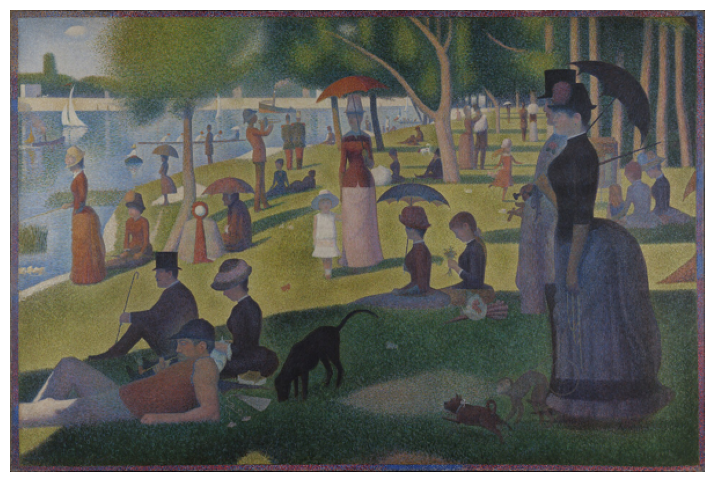

color: (399, 600, 3)  key: (399, 600)


In [4]:
# load the Grande Jatte, small enough to experiment on quickly
from PIL import Image

original = Image.open("../assets/images/seurat_grande_jatte.jpg")
work_w = 600
work_h = int(original.height * work_w / original.width)
seurat = np.asarray(original.resize((work_w, work_h))) / 255
# the luminance key: chapter 13's grayscale conversion, kept alongside the color
luminance = np.asarray(original.convert("L").resize((work_w, work_h))) / 255

plt.figure(figsize=(9, 6))
plt.imshow(seurat)
plt.axis("off")
plt.show()
print("color:", seurat.shape, " key:", luminance.shape)

## Total destruction, one column at a time

Start honestly, with the crudest possible move: pick one column of the image and sort it, all of it, by luminance.

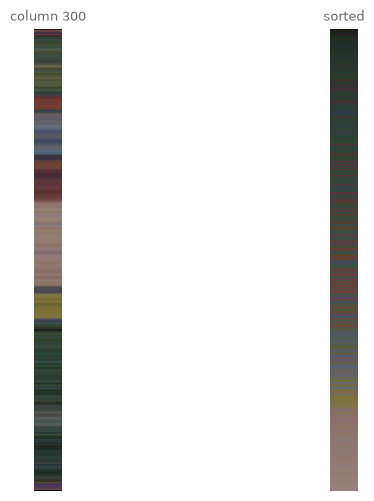

In [5]:
# sort a single column of pixels, fully, by brightness
col = 300
column_rgb = seurat[:, col]                 # all rows of one column: (height, 3)
column_key = luminance[:, col]
sorted_column = column_rgb[np.argsort(column_key)]

fig, axes = plt.subplots(1, 2, figsize=(7, 6))
# each column shown 24 pixels wide so it is visible; np.tile from chapter 13
axes[0].imshow(np.tile(column_rgb[:, None], (1, 24, 1)))
axes[0].set_title(f"column {col}", fontsize=9, color="#6B6B6B")
axes[1].imshow(np.tile(sorted_column[:, None], (1, 24, 1)))
axes[1].set_title("sorted", fontsize=9, color="#6B6B6B")
for ax in axes:
    ax.axis("off")
plt.show()

The left strip still remembers the painting: sky, tree, grass, shadow, in Seurat's order. The right strip is the same paint poured through a sieve: a single smooth pour from shadow-black to sky-white. Now do that to every column at once. `np.argsort(..., axis=0)` sorts each column independently, and one pair of index arrays applies all six hundred reorderings in a single line (`full_order` says, for every output cell, which row of its own column to take; `columns` simply repeats each column's number so the pairing lines up).

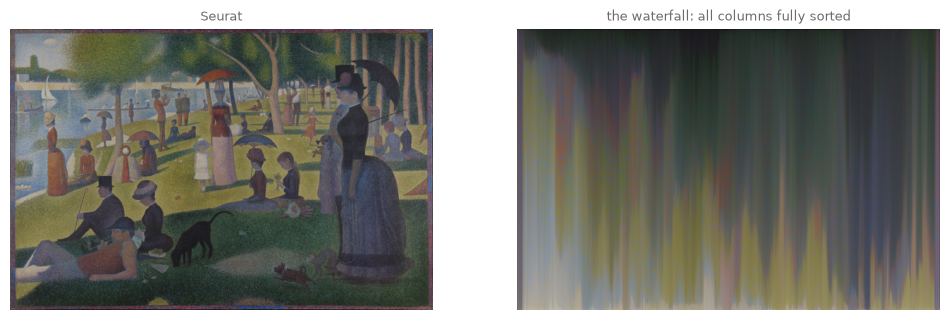

In [6]:
# the waterfall: every column fully sorted, the painting dissolves
full_order = np.argsort(luminance, axis=0)       # one ordering per column
columns = np.arange(work_w)[None, :]             # paired with each column's order
waterfall = seurat[full_order, columns]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].imshow(seurat)
axes[0].set_title("Seurat", fontsize=9, color="#6B6B6B")
axes[1].imshow(waterfall)
axes[1].set_title("the waterfall: all columns fully sorted", fontsize=9,
                  color="#6B6B6B")
for ax in axes:
    ax.axis("off")
plt.show()

Total sorting is total loss. The waterfall has a certain drama (the palette survives, arranged into a spectral rain), but *nothing of the picture* survives: composition, figures, depth, all gone. Every image sorted this way looks like every other image sorted this way, differing only in palette. As art, it is a dead end that took one line to reach.

The insight that turned pixel sorting from a party trick into a genre, the one Asendorf's script encodes, is this: **do not sort everything**. Choose a band of brightness, find the *contiguous runs* of pixels inside that band, and sort each run separately, in place. Pixels outside the band never move, so they hold the image together; pixels inside the band melt. Failure needs structure to be legible as failure.

**Try it.** Before reading on: in the waterfall cell, replace `luminance` with `-luminance` inside the `argsort`. The pour flips upside down. Aiming the *direction* of failure is already a choice.

## Finding the runs

A **run** (also called an interval) is a maximal stretch of consecutive `True` pixels in a column of the mask. The concept is one loop with a memory: walk down the column, note where you *enter* the band, note where you *leave* it. We write that loop first, because it is the heart of the chapter, and the fast version afterward.

In [7]:
# the honest version: walk down one column, remember where runs start and end
def find_runs(mask_column):
    runs = []
    start = None                       # None: we are currently outside a run
    for row, inside in enumerate(mask_column):
        if inside and start is None:
            start = row                # entering a run
        if not inside and start is not None:
            runs.append((start, row))  # leaving: the run was [start, row)
            start = None
    if start is not None:              # a run may reach the bottom edge
        runs.append((start, len(mask_column)))
    return runs

demo_mask = np.array([0, 1, 1, 1, 0, 0, 1, 1, 0, 1], dtype=bool)
print("mask:", demo_mask.astype(int))
print("runs:", find_runs(demo_mask))

mask: [0 1 1 1 0 0 1 1 0 1]
runs: [(1, 4), (6, 8), (9, 10)]


Three runs: rows 1 to 3, rows 6 to 7, and row 9 alone (each pair means "from the first number up to, but not including, the second", the same half-open convention as `range` and slicing, chapter 0).

The fast version replaces the loop with `np.diff`, which reports each element's difference from the one before. Applied to the mask, the differences are 0 everywhere except at the steps: +1 where the mask enters a run, -1 where it leaves one. Padding a `False` onto both ends catches runs that touch the edges.

In [8]:
# the fast version: run boundaries are the steps in the mask
def find_runs_fast(mask_column):
    padded = np.concatenate([[False], mask_column, [False]])
    steps = np.diff(padded.astype(int))     # +1 where a run enters, -1 where it exits
    starts = np.where(steps == 1)[0]
    ends = np.where(steps == -1)[0]
    return [(int(s), int(e)) for s, e in zip(starts, ends)]

print("loop:", find_runs(demo_mask))
print("fast:", find_runs_fast(demo_mask))
# check both agree on 200 random columns of real mask (chapter 13's habit)
check_rng = np.random.default_rng(14)
band = (luminance > 0.3) & (luminance < 0.8)
agree = all(find_runs(band[:, c]) == find_runs_fast(band[:, c])
            for c in check_rng.integers(0, work_w, 200))
print("agree on 200 real columns:", agree)

loop: [(1, 4), (6, 8), (9, 10)]
fast: [(1, 4), (6, 8), (9, 10)]


agree on 200 real columns: True


## The interval sort

Assemble the instrument. `pixel_sort` takes the color image, a key, and a brightness band; it masks the key into the band, finds each column's runs, and sorts each run by the key, in place. An optional `mask` argument lets you supply your own mask instead of the band (exercise (c) will want that), and `direction="horizontal"` simply hands the transposed image to the same function and transposes the answer back, one recursive call, as in chapter 4. (`transpose(1, 0, 2)` is `.T` for image arrays: it swaps rows and columns but leaves each pixel's three color values as a pixel.)

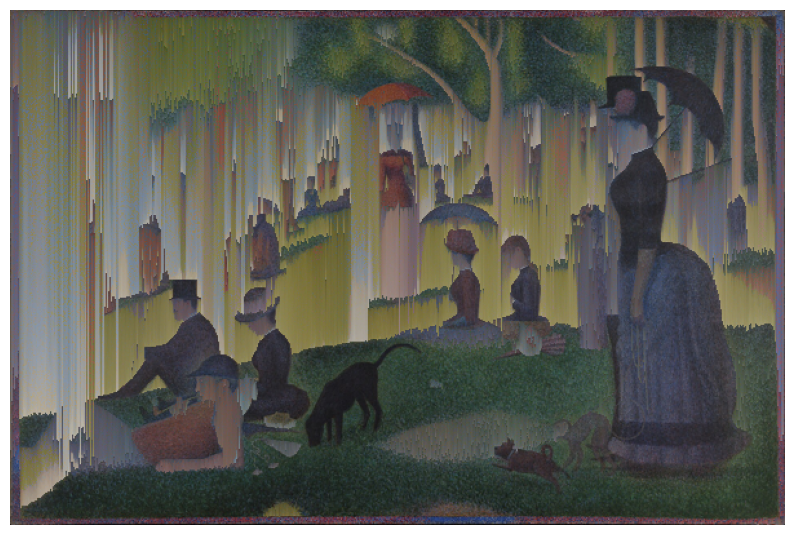

In [9]:
# the interval sort: melt only inside the band, hold everything else still
def pixel_sort(image, key, lo=0.25, hi=0.8, mask=None, direction="vertical"):
    if direction == "horizontal":      # sort rows = sort columns of the transpose
        turned = pixel_sort(image.transpose(1, 0, 2), key.T, lo, hi,
                            None if mask is None else mask.T)
        return turned.transpose(1, 0, 2)
    if mask is None:
        mask = (key >= lo) & (key <= hi)
    out = image.copy()
    for col in range(image.shape[1]):
        for start, end in find_runs_fast(mask[:, col]):
            segment_order = np.argsort(key[start:end, col])
            out[start:end, col] = image[start:end, col][segment_order]
    return out

melted = pixel_sort(seurat, luminance, lo=0.3, hi=0.8)

plt.figure(figsize=(10, 6.7))
plt.imshow(melted)
plt.axis("off")
plt.show()

There it is. The lawn streams, the water pours, and yet the painting is still unmistakably the *Grande Jatte*: the dark figures and the deep shadows sit below the band, the brightest sky above it, and they anchor everything the band melts. This image obeys both of chapter 13's masters at once: it is made entirely of faithful reproduction (every pixel is Seurat's) and entirely of failure (none of them is where he put it).

**Try it.** Narrow the band to `lo=0.55, hi=0.75` and the melt retreats into the mid-bright lawn only; the picture barely fails at all. Where between these settings and the waterfall does it *stop being a painting*? Hold that thought, it is exercise (a).

## Other keys, other failures

The band decides *where* the image melts; the key decides *what the melt looks like*. Luminance melts into brightness gradients. Hue melts into rainbows; saturation pulls gray toward color. Chapter 5 converted single colors to HSV with `colorsys`, one at a time; matplotlib's `rgb_to_hsv` does the whole image array at once.

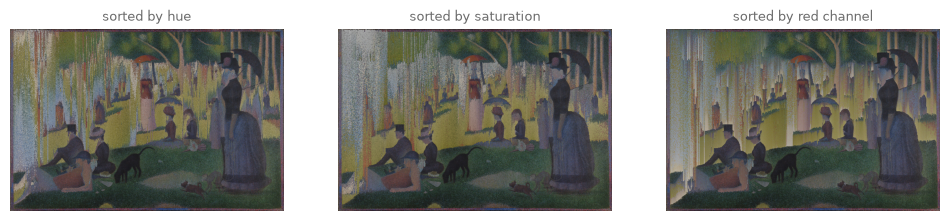

In [10]:
# three other keys: hue, saturation, one raw channel
from matplotlib.colors import rgb_to_hsv

hsv = rgb_to_hsv(seurat)               # hue 0..1, saturation 0..1, value 0..1
keys = {"hue": hsv[..., 0], "saturation": hsv[..., 1], "red channel": seurat[..., 0]}

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, (name, key) in zip(axes, keys.items()):
    # same luminance band decides WHERE; the named key decides the ORDER inside
    variant = pixel_sort(seurat, key, mask=(luminance > 0.3) & (luminance < 0.8))
    ax.imshow(variant)
    ax.set_title(f"sorted by {name}", fontsize=9, color="#6B6B6B")
    ax.axis("off")
plt.show()

Same mask, three temperaments. The hue sort files Seurat's dots by color family, so each run becomes a tiny rainbow inventory of the paint in that stretch; the saturation sort pushes his grayest dots to one end of each run; the red channel is a colorblind judge that produces the strangest, most chemical streaks. None of these is more correct than another. The key is a *curatorial* choice, exactly as the palette was in chapter 2.

## The parameter walk

The finished instrument has four dials: band low, band high, key, direction. The band is the one to learn by hand.

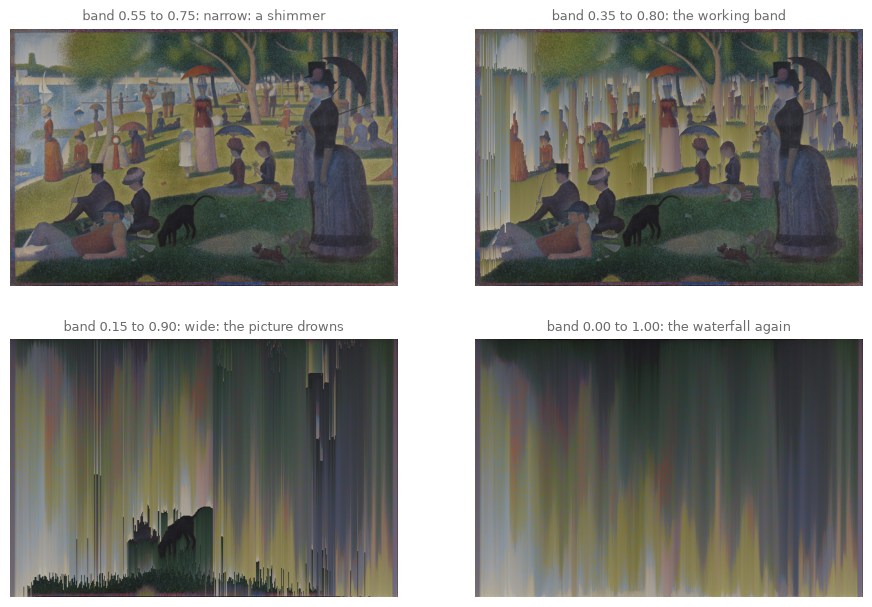

In [11]:
# four positions of the band: from barely touched to almost waterfall
band_studies = [(0.55, 0.75, "narrow: a shimmer"),
                (0.35, 0.80, "the working band"),
                (0.15, 0.90, "wide: the picture drowns"),
                (0.00, 1.00, "the waterfall again")]
fig, axes = plt.subplots(2, 2, figsize=(11, 7.4))
for ax, (lo, hi, label) in zip(axes.flat, band_studies):
    ax.imshow(pixel_sort(seurat, luminance, lo=lo, hi=hi))
    ax.set_title(f"band {lo:.2f} to {hi:.2f}: {label}", fontsize=9,
                 color="#6B6B6B")
    ax.axis("off")
plt.show()

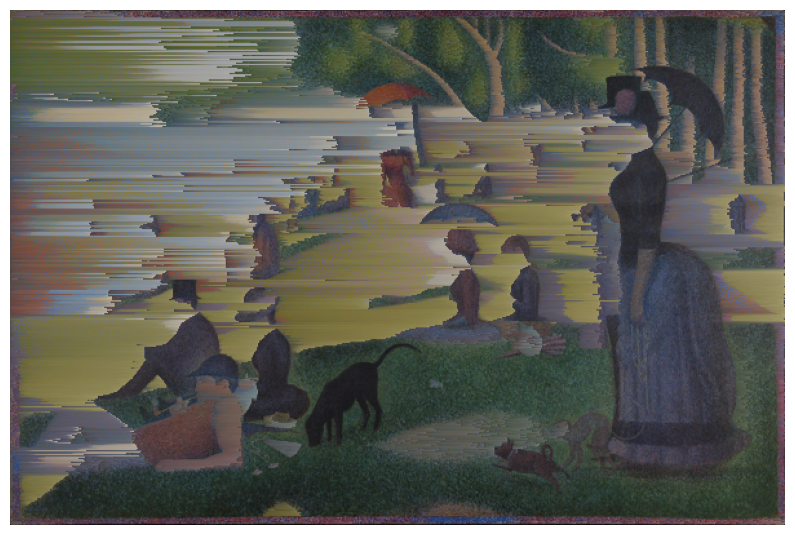

In [12]:
# and the direction dial: the same band, melting sideways
sideways = pixel_sort(seurat, luminance, lo=0.3, hi=0.8, direction="horizontal")

plt.figure(figsize=(10, 6.7))
plt.imshow(sideways)
plt.axis("off")
plt.show()

**Look and compare.** Vertical sorting reads as gravity: the painting melts, drips, rains. Horizontal sorting reads as motion or transmission error: the painting smears, streams sideways, loses horizontal hold like a failing broadcast (which is where this chapter began, with a magnet on a television). Which reading suits the *Grande Jatte*, a painting about stillness? Is the more *wrong* direction the more interesting one?

## Where the edge is sharpest (bonus)

The band masks by brightness, but nothing says it has to. Chapter 13's gradient magnitude knows where Seurat's edges are; using *low* gradient as the mask melts the calm regions and preserves every contour, a glitch that respects drawing.

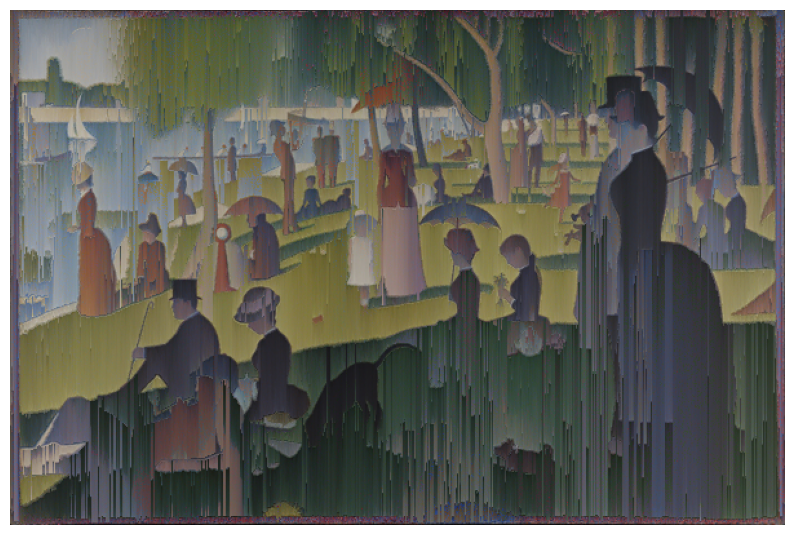

In [13]:
# bonus: sort where the painting is calm, hold where it has edges
from scipy.ndimage import convolve

sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
gradient = np.sqrt(convolve(luminance, sobel_x)**2
                   + convolve(luminance, sobel_x.T)**2)
calm = gradient < 0.35                  # well below a real edge (those reach ~4)

edge_respecting = pixel_sort(seurat, luminance, mask=calm)

plt.figure(figsize=(10, 6.7))
plt.imshow(edge_respecting)
plt.axis("off")
plt.show()

## Export your artwork

Any band, any key, any direction; other images from `assets/images/` are one filename away (the Hokusai melts beautifully sideways). Replace `yourname` and run. (The sorted array is saved at its working resolution; `np.kron`, chapter 9's pixel-art enlarger, last used in chapter 13, lifts it to print size with the streaks kept crisp.)

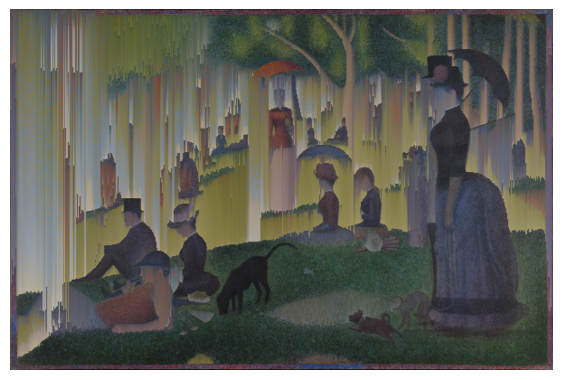

saved: assets/outputs/ch14_yourname.png


In [14]:
# save YOUR artwork: aim the failure, then replace 'yourname'
import sys
sys.path.append("..")
from agap.helpers import save_artwork, show

my_glitch = pixel_sort(seurat, luminance, lo=0.3, hi=0.8)
my_artwork = np.kron(my_glitch, np.ones((4, 4, 1)))    # 600 px wide -> 2400
show(my_artwork)
saved_path = save_artwork(my_artwork, "yourname", chapter=14)

## Exercises

**(a) Parameter exploration: the boundary of the painting.** Fix `hi=0.85` and walk `lo` downward: 0.6, 0.5, 0.4, 0.3, 0.2, 0.1. Somewhere on that walk the image stops being a glitched painting and becomes colored streaks with debris. Find *your* boundary and defend it in one written sentence: what, concretely, is the last thing that has to survive for the *Grande Jatte* to still be present? (There is no correct answer; there are defended and undefended ones.)

**(b) Code modification: melt one color family.** So far the *mask* has always come from brightness. Build it from **hue** instead, so that only Seurat's greens melt: the lawn streams away while the sky, the water and the figures stand still. Sort the greens by luminance as usual.

<details><summary>Solution</summary>

```python
hsv = rgb_to_hsv(seurat)
hue = hsv[..., 0]
greens = (hue > 0.2) & (hue < 0.45)      # the hue band of the lawn
lawn_melt = pixel_sort(seurat, luminance, mask=greens)
show(lawn_melt)
```

One caveat, promised in chapter 5: hue is *circular*. Red sits at both ends of the scale, near 0 and near 1, so a single band like the greens' can never capture "the reds"; you would need two bands joined with `|`. The same circularity is why *sorting by* hue (as in the key studies above) treats two nearly identical reds as maximally far apart when they straddle the wrap-around point.
</details>

**(c) Creative challenge: the borrowed mask.** The `mask` argument accepts any True/False image of the right shape, and this book is full of machines that make exactly those. Feed one system's output to another: threshold a chapter 9 rule-110 spacetime diagram, or chapter 12's Voronoi cells (color half the cells True), resize the result to the painting's shape, and pass it as `mask`. (A boolean mask resizes like an image: `Image.fromarray((small_mask * 255).astype(np.uint8)).resize((width, height))`, then threshold the result back to True/False.) The painting now melts *in the pattern of another system*: a cellular automaton deciding where a Seurat fails. Name the piece so the debt is visible, and bring it to the gallery.

## Further reading

- Rosa Menkman, *The Glitch Moment(um)* (Network Notebooks 04, Institute of Network Cultures, 2011), free PDF online: the theory of the aesthetics of error, by its central theorist; short and quotable.
- Iman Moradi, Ant Scott, Joe Gilmore and Christopher Murphy, *Glitch: Designing Imperfection* (Mark Batty Publisher, 2009): a visual survey of glitch aesthetics from before the pixel-sorting wave.
- Satyarth Mishra Sharma, "Pixel Sorting" (satyarth.me/articles/pixel-sorting): a technical walkthrough of exactly the interval technique in this chapter, tracing it back to Asendorf's script.
- Kim Cascone, "The Aesthetics of Failure: 'Post-Digital' Tendencies in Contemporary Computer Music", *Computer Music Journal* 24/4 (2000): the essay that named the mood; written about sound, true of images.

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook, sorting the *Grande Jatte* at its full resolution. One adjustment is needed there: at full size, Seurat's individual dots pepper the brightness band with tiny holes, chopping every run short and taming the melt (our 600-pixel working copy escaped this because shrinking an image *is* a blur). So the mask is computed from a blurred copy of the key (chapter 13's blur, one `gaussian_filter` call) while the *sorting* still uses the raw key; the runs grow long again and the cascade returns at full silkiness. `np.kron` then doubles the result to print size. Give it a few seconds: the run-sorting loop visits every one of the 1920 columns in pure Python. It runs automatically with *Restart & Run All*.

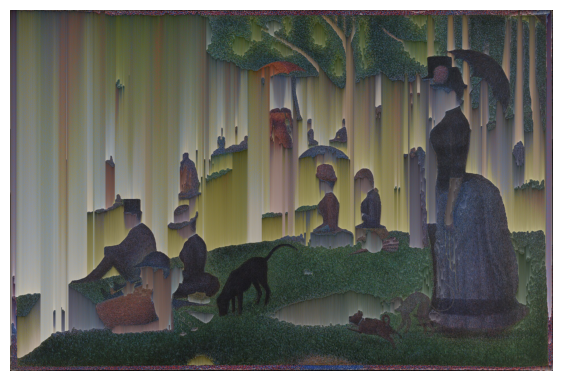

saved: assets/outputs/ch14_showpiece.png


In [15]:
# regenerate this chapter's showpiece: the interval-sorted Grande Jatte
from scipy.ndimage import gaussian_filter

big = np.asarray(original) / 255
big_key = np.asarray(original.convert("L")) / 255
# blur only the mask's copy of the key, so dots stop chopping the runs short
smooth_key = gaussian_filter(big_key, sigma=3)
big_mask = (smooth_key >= 0.3) & (smooth_key <= 0.8)
big_sorted = pixel_sort(big, big_key, mask=big_mask)
showpiece = np.kron(big_sorted, np.ones((2, 2, 1)))
show(showpiece)
saved_path = save_artwork(showpiece, "showpiece", chapter=14)